# Customer Churn Prediction in a Streaming Service

## Phase 1 — Business Understanding

- **Business problem:** Rising customer churn in a streaming service.
- **Goal:** Identify likely churners early enough for targeted retention.
- **Success criteria:** Strong accuracy, precision, and recall on churn prediction.
- **Risks:** Missing values, small sample size, privacy constraints, and CRM integration.
- **Data science framing:** Binary classification problem with `Churn` as `Yes`/`No`.
## Phase 2 — Data Understanding

This section loads the churn dataset and performs:

- dataset overview
- target distribution analysis
- exploratory visualizations

In [24]:
# load required libraries and dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'customer_churn_intermediate.csv'
df = pd.read_csv(file_path)

# overview
print("First few rows")
df.head()

First few rows


,UserID,Monthly_Fee,Tenure_Months,Age,Customer_Service_Calls,Churn
0,1000,19.99,46,20.0,1,Yes
1,1001,9.99,36,28.0,0,No
2,1002,19.99,45,62.0,1,Yes
3,1003,19.99,8,21.0,1,No
4,1004,9.99,29,43.0,0,No


In [25]:
#Dataset shape and variable types
print(f"Observations: {df.shape[0]}")
print(f"Variables:    {df.shape[1]}")
print()
print("Variable types:")
print(df.dtypes)
print()

#Summary statistics
print("Summary statistics:")
df.describe()

Observations: 2000
Variables:    6

Variable types:
UserID                      int64
Monthly_Fee               float64
Tenure_Months               int64
Age                       float64
Customer_Service_Calls      int64
Churn                         str
dtype: object

Summary statistics:


,UserID,Monthly_Fee,Tenure_Months,Age,Customer_Service_Calls
count,2000.000000,2000.000000,2000.000000,1800.000000,2000.000000
mean,1999.500000,14.897500,29.791500,43.633889,1.438000
std,577.494589,4.094182,16.878432,14.815743,1.148832
min,1000.000000,9.990000,1.000000,18.000000,0.000000
25%,1499.750000,9.990000,15.000000,31.000000,1.000000
50%,1999.500000,14.990000,30.000000,44.000000,1.000000
75%,2499.250000,19.990000,44.000000,56.000000,2.000000
max,2999.000000,19.990000,59.000000,69.000000,6.000000


Churn distribution:
  No: 1604 (80.2%)
  Yes: 396 (19.8%)


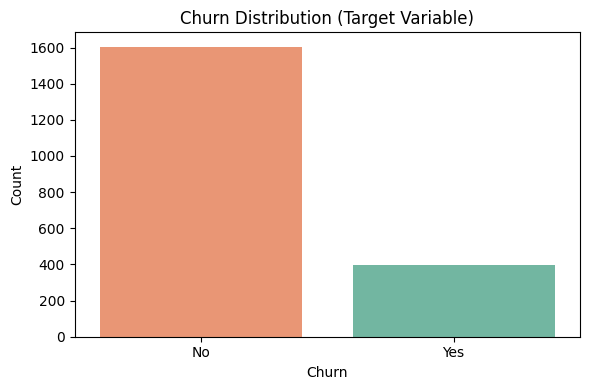

In [26]:
#Target variable analysis: Churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn distribution:")
for label in churn_counts.index:
    print(f"  {label}: {churn_counts[label]} ({churn_pct[label]:.1f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x='Churn',
    order=['No', 'Yes'],
    hue='Churn',
    palette='Set2',
    legend=False
)
plt.title('Churn Distribution (Target Variable)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

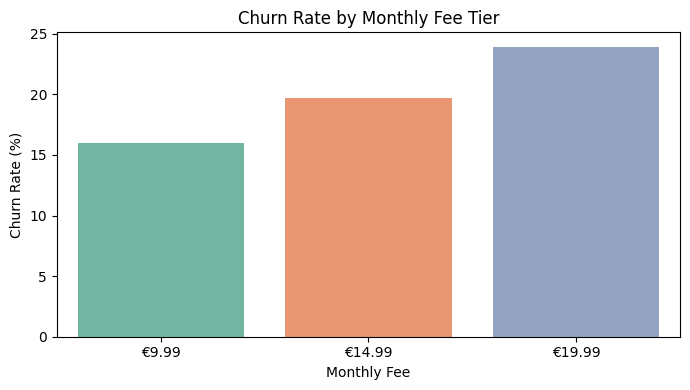

Business interpretation:
Customers on higher-priced plans may show different churn behaviour.
If churn is concentrated in a specific tier, pricing strategy may need review.


In [27]:
#Visualization 1: Churn rate by Monthly Fee tier
churn_by_fee = df.groupby('Monthly_Fee')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_by_fee.columns = ['Monthly_Fee', 'Churn_Rate_%']
churn_by_fee['Monthly_Fee'] = churn_by_fee['Monthly_Fee'].apply(lambda x: f'€{x:.2f}')

plt.figure(figsize=(7, 4))
sns.barplot(
    data=churn_by_fee,
    x='Monthly_Fee',
    y='Churn_Rate_%',
    hue='Monthly_Fee',
    palette='Set2',
    legend=False
)
plt.title('Churn Rate by Monthly Fee Tier')
plt.xlabel('Monthly Fee')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Business interpretation:")
print("Customers on higher-priced plans may show different churn behaviour.")
print("If churn is concentrated in a specific tier, pricing strategy may need review.")

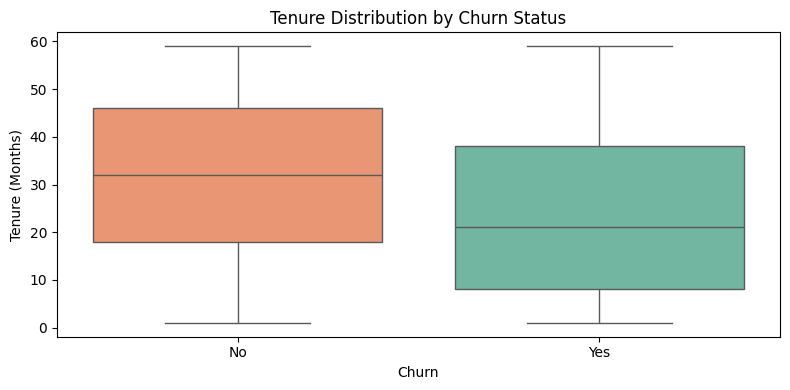

Business interpretation:
Shorter-tenured customers who churn suggest early-stage dissatisfaction.
A bimodal pattern (if present) could indicate two distinct churn risk groups.


In [28]:
#Visualization 2: Tenure vs Churn
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x='Churn',
    y='Tenure_Months',
    order=['No', 'Yes'],
    hue='Churn',
    palette='Set2',
    legend=False
)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

print("Business interpretation:")
print("Shorter-tenured customers who churn suggest early-stage dissatisfaction.")
print("A bimodal pattern (if present) could indicate two distinct churn risk groups.")

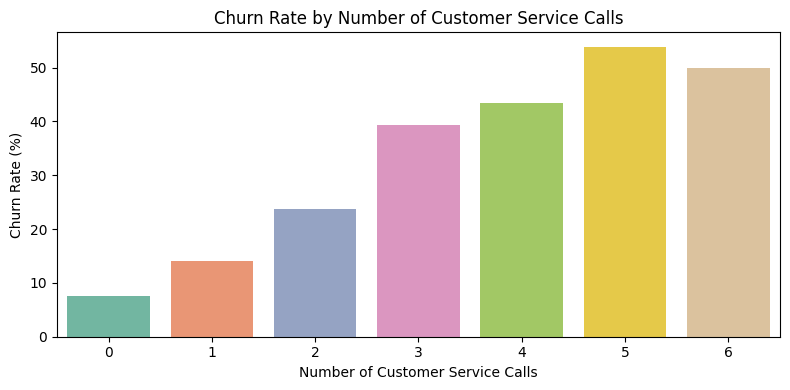

Business interpretation:
A rising churn rate with more customer service calls strongly suggests
that unresolved issues drive churn. Customers who call frequently are
expressing frustration — a high-priority group for proactive retention.


In [29]:
#Visualization 3: Customer Service Calls vs Churn
churn_by_calls = df.groupby('Customer_Service_Calls')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_by_calls.columns = ['Customer_Service_Calls', 'Churn_Rate_%']

plt.figure(figsize=(8, 4))
sns.barplot(
    data=churn_by_calls,
    x='Customer_Service_Calls',
    y='Churn_Rate_%',
    hue='Customer_Service_Calls',
    palette='Set2',
    legend=False
)
plt.title('Churn Rate by Number of Customer Service Calls')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Business interpretation:")
print("A rising churn rate with more customer service calls strongly suggests")
print("that unresolved issues drive churn. Customers who call frequently are")
print("expressing frustration — a high-priority group for proactive retention.")

**Initial Insights**

The exploratory analysis reveals several important patterns:

- The dataset contains **2,000 customer records** with **6 variables** covering demographics, subscription details, and service behaviour.
- The **churn rate is approximately 19.8%**, meaning roughly 1 in 5 customers has left the service. This aligns with the business concern and confirms that churn is a substantial, measurable problem.
- **Monthly fee tier** appears to differentiate churn rates across pricing segments, suggesting that plan type may be a meaningful predictor.
- **Tenure** shows a visible difference between churned and retained customers. Lower-tenure customers appear more likely to churn, indicating a critical early period in the customer lifecycle.
- **Customer service calls** show a clear positive relationship with churn. Customers making more calls are disproportionately likely to churn, making this variable a strong candidate predictor.

## Phase 3 — Data Preparation

Prepare the dataset for reliable modelling and analysis by handling quality issues:

- **Missing values** – detect and describe handling strategy (drop or impute).
- **Duplicate records** – identify and remove exact duplicates.
- **Data errors and inconsistencies** – look for negative numbers, wrong categories, unrealistic values, and incorrect data types.


**References**
- Verbeke, W., Dejaeger, K., Martens, D., Hur, J., & Baesens, B. (2012). New insights into churn prediction in the telecommunication sector: A profit driven data mining approach. *European Journal of Operational Research*, 218(1), 211–229.
- Huang, B., Kechadi, M. T., & Buckley, B. (2012). Customer churn prediction in telecommunications. *Expert Systems with Applications*, 39(1), 1414–1425.

In [30]:
#Missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Age has 200 missing values (10% of data)
# Strategy: impute with the median — robust to skew and avoids discarding records
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print(f"Age missing values imputed with median: {age_median}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Missing values per column:
UserID                      0
Monthly_Fee                 0
Tenure_Months               0
Age                       200
Customer_Service_Calls      0
Churn                       0
dtype: int64

Age missing values imputed with median: 44.0
Remaining missing values: 0


In [31]:
#Duplicate records
dup_count = df.duplicated().sum()
print(f"Duplicate records found: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found — no action needed.")

Duplicate records found: 0
No duplicates found — no action needed.


In [32]:
# Data errors and inconsistencies

# Check for negative values in numeric columns
print("Negative values in numeric columns:")
for col in ['Monthly_Fee', 'Tenure_Months', 'Customer_Service_Calls', 'Age']:
    neg = (df[col] < 0).sum()
    print(f"  {col}: {neg} negative values")

print()

# Check Churn column for unexpected categories
print("Churn column unique values:", df['Churn'].unique())

print()

# Check Monthly_Fee for unexpected values (should only be 9.99, 14.99, 19.99)
print("Monthly_Fee unique values:", sorted(df['Monthly_Fee'].unique()))

print()

# Check Age for unrealistic values
print(f"Age range: {df['Age'].min()} – {df['Age'].max()}")

print()

# Check Tenure_Months for unrealistic values
print(f"Tenure range: {df['Tenure_Months'].min()} – {df['Tenure_Months'].max()} months")

Negative values in numeric columns:
  Monthly_Fee: 0 negative values
  Tenure_Months: 0 negative values
  Customer_Service_Calls: 0 negative values
  Age: 0 negative values

Churn column unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Monthly_Fee unique values: [np.float64(9.99), np.float64(14.99), np.float64(19.99)]

Age range: 18.0 – 69.0

Tenure range: 1 – 59 months


In [33]:
# Encode target variable and correct data types

# Convert Churn to binary integer (Yes = 1, No = 0) for modelling
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn encoded: Yes → 1, No → 0")
print("Churn value counts after encoding:")
print(df['Churn'].value_counts())
print()

# Drop UserID — it is an identifier, not a predictor
df_clean = df.drop(columns=['UserID'])
print("UserID column dropped (identifier, not a predictor).")
print()
print("Final cleaned dataset shape:", df_clean.shape)
print()
print("Final data types:")
print(df_clean.dtypes)

Churn encoded: Yes → 1, No → 0
Churn value counts after encoding:
Churn
0    1604
1     396
Name: count, dtype: int64

UserID column dropped (identifier, not a predictor).

Final cleaned dataset shape: (2000, 5)

Final data types:
Monthly_Fee               float64
Tenure_Months               int64
Age                       float64
Customer_Service_Calls      int64
Churn                       int64
dtype: object


In [34]:
# Save cleaned dataset and show preview 
df_clean.to_csv('customer_churn_cleaned.csv', index=False)
print("Cleaned dataset saved as 'customer_churn_cleaned.csv'")
print()
print("Clean dataset preview:")
df_clean.head()

Cleaned dataset saved as 'customer_churn_cleaned.csv'

Clean dataset preview:


,Monthly_Fee,Tenure_Months,Age,Customer_Service_Calls,Churn
0,19.99,46,20.0,1,1
1,9.99,36,28.0,0,0
2,19.99,45,62.0,1,1
3,19.99,8,21.0,1,0
4,9.99,29,43.0,0,0


## Phase 4 — Modeling

 Select, build, and train a machine learning model to predict customer churn. This phase translates the cleaned dataset from Phase 3 into a working predictive model, with decisions justified from both a technical and business perspective.

The following code cells cover:
- **Model selection** and rationale
- **Train/test split**
- **Model training**
- **Prediction output**

In [35]:
# Import modeling libraries 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Reload cleaned data (if running independently)
df_model = pd.read_csv('customer_churn_cleaned.csv')

print("Dataset loaded for modeling.")
print(f"Shape: {df_model.shape}")
df_model.head()

Dataset loaded for modeling.
Shape: (2000, 5)


,Monthly_Fee,Tenure_Months,Age,Customer_Service_Calls,Churn
0,19.99,46,20.0,1,1
1,9.99,36,28.0,0,0
2,19.99,45,62.0,1,1
3,19.99,8,21.0,1,0
4,9.99,29,43.0,0,0


**Model Selection Rationale**

A **Decision Tree Classifier** remains a good fit for this task because it is both practical and explainable.

- **Interpretability:** The model produces human-readable decision rules, which helps stakeholder trust and supports GDPR explainability.
- **Business alignment:** Retention teams can more easily understand why a customer is flagged as high risk.
- **Imbalance handling:** Because churn cases are the minority class, the model is tuned with `class_weight='balanced'` so it gives more attention to likely churners instead of mostly predicting non-churn.

In [36]:
# Define features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print("Features used for modeling:")
print(list(X.columns))
print()
print(f"Target variable: Churn (0 = No, 1 = Yes)")

Features used for modeling:
['Monthly_Fee', 'Tenure_Months', 'Age', 'Customer_Service_Calls']

Target variable: Churn (0 = No, 1 = Yes)


In [37]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} records")
print(f"Test set size:     {X_test.shape[0]} records")
print()
print(f"Churn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set:     {y_test.mean()*100:.1f}%")

Training set size: 1600 records
Test set size:     400 records

Churn rate in training set: 19.8%
Churn rate in test set:     19.8%


In [38]:
# Train the tuned Decision Tree model 
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Using a class-balanced tree to improve churn detection.")
print(f"Max tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model trained successfully.
Using a class-balanced tree to improve churn detection.
Max tree depth: 4
Number of leaves: 16


In [39]:
# Generate predictions on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of churn

print("Predictions generated.")
print()
print("Sample predictions (first 10 rows):")
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Churn_Probability': y_prob[:10].round(2)
})
print(results.to_string(index=False))

Predictions generated.

Sample predictions (first 10 rows):
 Actual  Predicted  Churn_Probability
      0          1               0.60
      1          0               0.24
      0          1               0.54
      0          0               0.33
      0          1               0.54
      0          1               0.54
      0          1               0.54
      0          1               0.55
      0          0               0.02
      0          1               0.94


## Phase 5 — Evaluation


- **Model performance metrics** such as accuracy, precision, recall, and F1-score
- **Confusion matrix** to understand error types
- **Feature importance** to identify the strongest churn drivers
- **Business evaluation** to connect the results back to the retention goals

In [40]:
# Classification report 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("Model Performance on Test Set")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print(f"F1-score:  {f1_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'], zero_division=0))

Model Performance on Test Set
Accuracy:  60.2%
Precision: 30.2%
Recall:    77.2%
F1-score:  43.4%



              precision    recall  f1-score   support

    No Churn       0.91      0.56      0.69       321
       Churn       0.30      0.77      0.43        79

    accuracy                           0.60       400
   macro avg       0.61      0.67      0.56       400
weighted avg       0.79      0.60      0.64       400



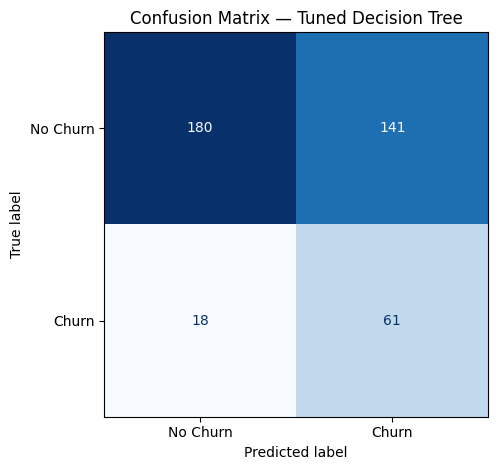

True Negatives  (correctly predicted no churn): 180
False Positives (wrongly flagged as churn):     141
False Negatives (missed churners):              18
True Positives  (correctly predicted churn):    61


In [41]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])

disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Tuned Decision Tree')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted no churn): {tn}")
print(f"False Positives (wrongly flagged as churn):     {fp}")
print(f"False Negatives (missed churners):              {fn}")
print(f"True Positives  (correctly predicted churn):    {tp}")

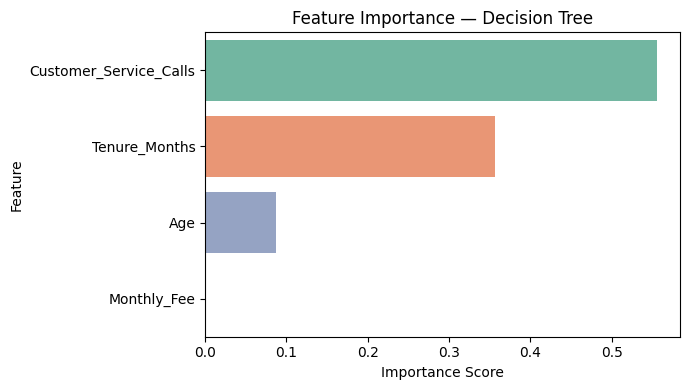

Feature importance ranking:
  Customer_Service_Calls: 0.5563
  Tenure_Months: 0.3563
  Age: 0.0874
  Monthly_Fee: 0.0000


In [42]:
# Feature importance
importance_df = (
    pd.Series(model.feature_importances_, index=X.columns, name='Importance')
    .sort_values(ascending=False)
    .reset_index()
)
importance_df.columns = ['Feature', 'Importance']

plt.figure(figsize=(7, 4))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Set2',
    legend=False
)
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

**Business Evaluation**

The tuned model gives a more useful balance for customer retention work:

- **Recall is much stronger** than the earlier version, meaning the business can identify many more likely churners before they leave.
- **Precision remains modest**, so some customers will be flagged unnecessarily, but this is often acceptable for a targeted retention campaign.
- **Accuracy is lower than the original baseline**, because the model is now prioritising churn detection instead of mostly predicting non-churn.
- **Feature importance** continues to highlight `Customer_Service_Calls` and `Tenure_Months` as the strongest churn drivers.

**Limitations**

- The dataset is relatively small, with only 2,000 records.
- `Monthly_Fee` has only three distinct plan values.
- The model does not yet include richer behavioural variables such as usage frequency or content preferences.
- Median imputation for missing ages introduces some uncertainty.

## Phase 6 — Deployment

**Deployment Strategy**

The model can be deployed as a **risk scoring layer in the CRM system**. Each week, active customers receive a churn probability score, and high-risk customers are flagged for targeted retention action.

### Key operational points
- Start with a small pilot rollout before full deployment.
- Give retention agents a ranked list of at-risk customers.
- Monitor accuracy and retrain the model regularly to reduce drift.
- Keep human oversight in place for GDPR compliance and fair treatment of customers.

In [43]:
# Temporary model comparison to improve churn detection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

candidate_models = {
    'DecisionTree_default': DecisionTreeClassifier(max_depth=4, random_state=42),
    'DecisionTree_balanced': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, class_weight='balanced', random_state=42),
    'RandomForest_balanced': RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )
}

comparison_rows = []
for name, candidate in candidate_models.items():
    candidate.fit(X_train, y_train)
    pred = candidate.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
    comparison_rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 3),
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1': round(f1, 3)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(by=['F1', 'Recall', 'Accuracy'], ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1
1,DecisionTree_balanced,0.630,0.305,0.684,0.422
2,RandomForest_balanced,0.680,0.324,0.570,0.413
0,DecisionTree_default,0.797,0.400,0.051,0.090


In [44]:
# Additional tuning for a better business-friendly churn model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
log_model.fit(X_train, y_train)
log_probs = log_model.predict_proba(X_test)[:, 1]

threshold_rows = []
for model_name, probs in [('RandomForest', rf_probs), ('LogisticRegression', log_probs)]:
    for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
        pred = (probs >= threshold).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
        threshold_rows.append({
            'Model': model_name,
            'Threshold': threshold,
            'Accuracy': round(accuracy_score(y_test, pred), 3),
            'Precision': round(precision, 3),
            'Recall': round(recall, 3),
            'F1': round(f1, 3)
        })

threshold_df = pd.DataFrame(threshold_rows).sort_values(by=['F1', 'Recall', 'Accuracy'], ascending=False)
threshold_df.head(10)

,Model,Threshold,Accuracy,Precision,Recall,F1
9,LogisticRegression,0.50,0.665,0.323,0.633,0.427
8,LogisticRegression,0.45,0.623,0.304,0.709,0.426
7,LogisticRegression,0.40,0.562,0.276,0.747,0.403
2,RandomForest,0.40,0.645,0.299,0.595,0.398
0,RandomForest,0.30,0.537,0.268,0.772,0.397
5,LogisticRegression,0.30,0.465,0.255,0.886,0.395
6,LogisticRegression,0.35,0.510,0.261,0.810,0.395
1,RandomForest,0.35,0.590,0.275,0.658,0.388
3,RandomForest,0.45,0.662,0.297,0.519,0.378
4,RandomForest,0.50,0.695,0.316,0.468,0.378


In [45]:
#  Decision Tree tuning for class imbalance
from itertools import product

search_rows = []
for depth, leaf in product([3, 4, 5, 6, 7, None], [5, 10, 15, 20]):
    tuned_tree = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=leaf,
        class_weight='balanced',
        random_state=42
    )
    tuned_tree.fit(X_train, y_train)
    pred = tuned_tree.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
    search_rows.append({
        'max_depth': depth,
        'min_samples_leaf': leaf,
        'accuracy': round(accuracy_score(y_test, pred), 3),
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1': round(f1, 3)
    })

pd.DataFrame(search_rows).sort_values(by=['f1', 'recall', 'accuracy'], ascending=False).head(10)

,max_depth,min_samples_leaf,accuracy,precision,recall,f1
5,4.0,10,0.603,0.302,0.772,0.434
6,4.0,15,0.603,0.302,0.772,0.434
7,4.0,20,0.618,0.305,0.734,0.431
4,4.0,5,0.595,0.298,0.772,0.430
0,3.0,5,0.575,0.288,0.785,0.422
1,3.0,10,0.575,0.288,0.785,0.422
2,3.0,15,0.575,0.288,0.785,0.422
3,3.0,20,0.575,0.288,0.785,0.422
9,5.0,10,0.630,0.305,0.684,0.422
8,5.0,5,0.642,0.307,0.646,0.416
